# Welche Spielstatistiken erklären den Erfolg von PGA-Tour-Profis?

## 1. Einleitung

Golf kann man in mehrere Bereiche unterteilen, lange Schläge, Annäherungenschläge, kurze Schläge, Putten. Die PGA
Tour erfasst für jede Saison Durchschnittswerte zu diesen Bereichen. Nun kann man sich die Frage stellen: welche dieser
Statistiken hängt am stärksten mit Erfolg zusammen?

Erfolg messen wir auf folgende drei Arten: Scoring Average (Schlagdurchschnitt pro Runde), Preisgeld einer Saison und
Rang in der FedExCup-Wertung.

Wir haben folgende Vermutungen angestellt:
- Driving Distance und GIR sollten das Scoring Average verbessern
- Bei Preisgeld und Rang erwarte wir, dass Scrambling und Putts wichtiger werden, weil dort vorallem das
kurze Spiel unter zählt.


Wir verwenden folgende Methoden:

Eine lineare Regression beschreibt eine Zielgröße $y$ über einen Prädiktor $x$, mit
$y = a_0 + a_1 x + \varepsilon$. Gesucht sind die Werte für $a_0$ und $a_1$, die die Residuenquadratsumme

$$RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

minimieren. $R^2$ zeigt dann, wie viel von der Varianz in $y$ durch $x$ erklärt wird:

$$R^2 = 1 - \frac{RSS}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

Für die einfache Lesbarkeit, betrachten wir hier in den 15 Regressionen nur einen Prädiktor gegen eine Zielgröße.

## 2. Daten einlesen & aufbereiten

Verwendet wird der Datensatz "PGA Tour Data (2010-2018)".

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf

df = pd.read_csv("data/pgaTourData.csv")
df.shape

(2312, 18)

In [6]:
df.head()

,Player Name,Rounds,Fairway Percentage,Year,Avg Distance,gir,Average Putts,Average Scrambling,Average Score,Points,Wins,Top 10,Average SG Putts,Average SG Total,SG:OTT,SG:APR,SG:ARG,Money
0,Henrik Stenson,60.0,75.19,2018,291.5,73.51,29.93,60.67,69.617,868,NaN,5.0,-0.207,1.153,0.427,0.960,-0.027,"$2,680,487"
1,Ryan Armour,109.0,73.58,2018,283.5,68.22,29.31,60.13,70.758,"1,006",1.0,3.0,-0.058,0.337,-0.012,0.213,0.194,"$2,485,203"
2,Chez Reavie,93.0,72.24,2018,286.5,68.67,29.12,62.27,70.432,"1,020",NaN,3.0,0.192,0.674,0.183,0.437,-0.137,"$2,700,018"
3,Ryan Moore,78.0,71.94,2018,289.2,68.80,29.17,64.16,70.015,795,NaN,5.0,-0.271,0.941,0.406,0.532,0.273,"$1,986,608"
4,Brian Stuard,103.0,71.44,2018,278.9,67.12,29.11,59.23,71.038,421,NaN,3.0,0.164,0.062,-0.227,0.099,0.026,"$1,089,763"


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2312 entries, 0 to 2311
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Player Name         2312 non-null   str    
 1   Rounds              1678 non-null   float64
 2   Fairway Percentage  1678 non-null   float64
 3   Year                2312 non-null   int64  
 4   Avg Distance        1678 non-null   float64
 5   gir                 1678 non-null   float64
 6   Average Putts       1678 non-null   float64
 7   Average Scrambling  1678 non-null   float64
 8   Average Score       1678 non-null   float64
 9   Points              2296 non-null   str    
 10  Wins                293 non-null    float64
 11  Top 10              1458 non-null   float64
 12  Average SG Putts    1678 non-null   float64
 13  Average SG Total    1678 non-null   float64
 14  SG:OTT              1678 non-null   float64
 15  SG:APR              1678 non-null   float64
 16  SG:ARG           

In [8]:
df.describe()

,Rounds,Fairway Percentage,Year,Avg Distance,gir,Average Putts,Average Scrambling,Average Score,Wins,Top 10,Average SG Putts,Average SG Total,SG:OTT,SG:APR,SG:ARG
count,1678.000000,1678.000000,2312.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,293.000000,1458.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000
mean,78.711561,61.440560,2013.996107,290.807688,65.661675,29.163331,58.115638,70.921961,1.218430,2.781893,0.025641,0.148105,0.037759,0.065015,0.019974
std,14.274137,5.058845,2.581176,8.916631,2.745411,0.518468,3.384769,0.698305,0.573443,1.895094,0.343787,0.694923,0.379892,0.380952,0.223361
min,45.000000,43.020000,2010.000000,266.400000,53.540000,27.510000,44.010000,68.698000,1.000000,1.000000,-1.475000,-3.209000,-1.717000,-1.680000,-0.930000
25%,69.000000,57.942500,2012.000000,284.900000,63.830000,28.810000,55.900000,70.494250,1.000000,1.000000,-0.187000,-0.254750,-0.190250,-0.180750,-0.123000
50%,79.500000,61.430000,2014.000000,290.550000,65.790000,29.140000,58.275000,70.902000,1.000000,2.000000,0.040000,0.147000,0.056000,0.081000,0.022000
75%,89.000000,64.910000,2016.000000,296.400000,67.580000,29.520000,60.420000,71.342750,1.000000,4.000000,0.257000,0.568500,0.291500,0.314500,0.175000
max,120.000000,76.880000,2018.000000,319.700000,73.520000,31.000000,69.330000,74.400000,5.000000,14.000000,1.130000,2.406000,1.485000,1.533000,0.660000


Die Spalten im Rohdatensatz tragen andere Namen als die Variablen, um die es hier geht:

| Variable | Spalte im Rohdatensatz |
|---|---|
| Scoring Average | `Average Score` |
| Preisgeld | `Money` |
| Rang | abgeleitet aus `Points` |
| Driving Distance | `Avg Distance` |
| Driving Accuracy | `Fairway Percentage` |
| Greens in Regulation % | `gir` |
| Putts pro Runde | `Average Putts` |
| Scrambling % | `Average Scrambling` |

`Rounds`, `Wins`, `Top 10` und die `Strokes-Gained-Spalten` nutzen wir nicht.

Zwei Spalten `Points` und `Money` müssen nun noch nutzbar gemacht werden, indem wir die Trennzeichen und Dollarzeichen entfernen.

In [9]:
df["Points"] = pd.to_numeric(df["Points"].str.replace(",", "", regex=False), errors="coerce")
df["Money"] = pd.to_numeric(df["Money"].str.replace("[$,]", "", regex=True), errors="coerce")

Driving Distance, Fairway Percentage, GIR,Putts, Scrambling und Average Score fehlen bei genau denselben 634 Zeilen (über
isna().any(axis=1) haben wir das ermittelt). Vermutlich haben diese Spieler nicht genug Runden gespielt, um in die Statistik aufgenommen zu werden. Wir entfernen diese Zeilen.

In [10]:
spielstatistiken = ["Avg Distance", "Fairway Percentage", "gir", "Average Putts", "Average Scrambling", "Average Score"]
df = df.dropna(subset=spielstatistiken, how="all")
df.shape

(1678, 18)

Einen Rang gab es perse nicht im Rohdatensatz, deshalb erstellen wir eine Spalte `rank` aus `Points`.

In [11]:
df["rank"] = df.groupby("Year")["Points"].rank(ascending=False, method="min")

In [12]:
# hier benennen wir die Variablen für Verständnis und kürze um, es hat keinen methodischen Grund

spalten_umbenennen = {
    "Average Score": "scoring_avg",
    "Money": "money",
    "Avg Distance": "distance",
    "Fairway Percentage": "accuracy",
    "gir": "gir_pct",
    "Average Putts": "putts",
    "Average Scrambling": "scrambling",
}
df = df.rename(columns=spalten_umbenennen)

ziel_variablen = ["scoring_avg", "money", "rank"]
praediktoren = ["distance", "accuracy", "gir_pct", "putts", "scrambling"]


In [13]:
# Hier wird die Anzeige das Preisgeldes einfach in Millionen gewandelt, zur Lesbarkeit
def geld_achse(achse):
    achse.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

## 3. Explorative Datenanalyse

Hier haben wir uns, erneut für die Lesbarkeit, dazu entschieden, jedem Plot eine Zelle zu geben, damit wir nicht alle in eienm Raster darstellen müssen.

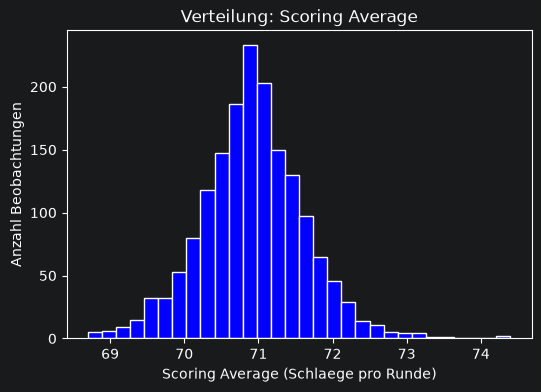

In [16]:
plt.figure(figsize=(6, 4))
plt.hist(df["scoring_avg"].dropna(), bins=30, color="blue", edgecolor="white")
plt.xlabel("Scoring Average (Schläge pro Runde)")
plt.ylabel("Anzahl Beobachtungen")
plt.title("Verteilung: Scoring Average")
plt.show()

Die meisten Spieler-Saisons liegen zwischen etwa 70 und 72 Schlägen im Schnitt, die Verteilung ist recht
symmetrisch um knapp 71 Schläge.

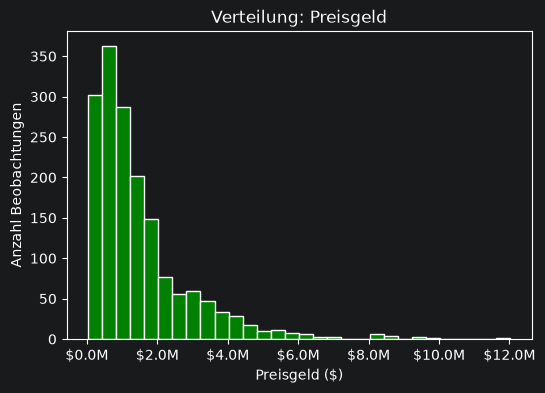

In [18]:
plt.figure(figsize=(6, 4))
plt.hist(df["money"].dropna(), bins=30, color="green", edgecolor="white")
ax = plt.gca()
geld_achse(ax.xaxis)
plt.xlabel("Preisgeld ($)")
plt.ylabel("Anzahl Beobachtungen")
plt.title("Verteilung: Preisgeld")
plt.show()

Der Median liegt bei rund 1,0 Mio. Dollar.
Der Mittelwert wegen einzelner Spieler
mit bis zu 12 Mio. Dollar aber bei knapp 1,5 Mio.

Da es 15 mögliche Streudiagramme gibt (3 Zielgrößen x 5 Prädiktoren), haben wir uns entschieden nur jeweils 2 mit der stärksten Korrelation zu zeigen.
Trotzdem werden alle 15 Regressionen in Abschnitt 4 vollständig berechnet,
hier geht es nur um eine Auswahl der gezeigten Diagramme.

In [13]:
ausgewaehlte_kombis = []
for ziel in ziel_variablen:
    korr = df[[ziel] + praediktoren].corr()[ziel].drop(ziel)
    top2 = korr.abs().sort_values(ascending=False).head(2).index.tolist()
    ausgewaehlte_kombis += [(ziel, p) for p in top2]

ausgewaehlte_kombis

[('scoring_avg', 'scrambling'),
 ('scoring_avg', 'gir_pct'),
 ('money', 'distance'),
 ('money', 'scrambling'),
 ('rank', 'scrambling'),
 ('rank', 'gir_pct')]

Scrambling taucht bei allen drei Zielgrößen unter den Top 2 auf, GIR bei zwei von drei.
Driving Accuracy und Putts pro Runde sind dagegen nirgends unter den stärksten zwei Prädiktoren.

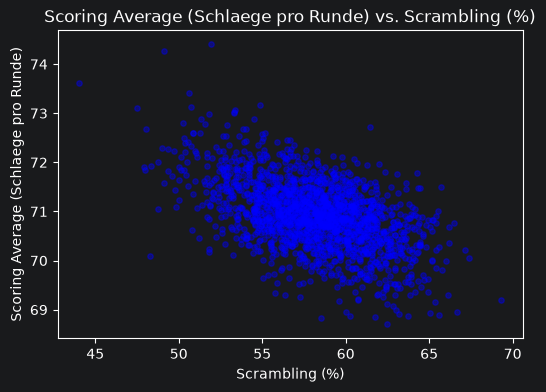

In [22]:
plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["scoring_avg"], alpha=0.4, s=15, color="blue")
plt.xlabel("Scrambling (%)")
plt.ylabel("Scoring Average (Schläge pro Runde)")
plt.title("Scoring Average (Schläge pro Runde) vs. Scrambling (%)")
plt.show()

Mit besserem Scrambling sinkt der Scoring Average sichtbar.

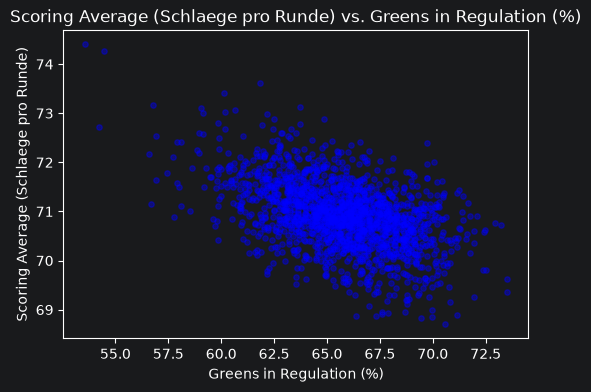

In [23]:
plt.figure(figsize=(6, 4))
plt.scatter(df["gir_pct"], df["scoring_avg"], alpha=0.4, s=15, color="blue")
plt.xlabel("Greens in Regulation (%)")
plt.ylabel("Scoring Average (Schläge pro Runde)")
plt.title("Scoring Average (Schläge pro Runde) vs. Greens in Regulation (%)")
plt.show()

Auch mehr getroffene Grüns senken den Scoring Average.

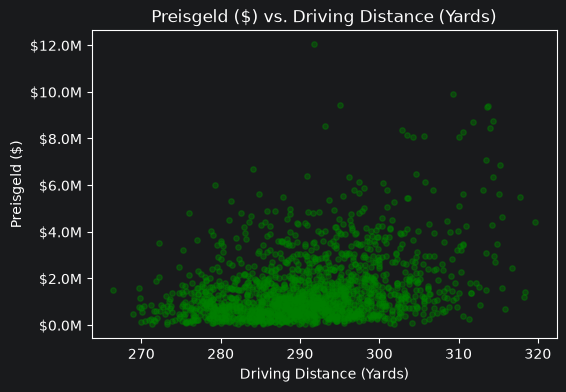

In [24]:
plt.figure(figsize=(6, 4))
plt.scatter(df["distance"], df["money"], alpha=0.4, s=15, color="green")
geld_achse(plt.gca().yaxis)
plt.xlabel("Driving Distance (Yards)")
plt.ylabel("Preisgeld ($)")
plt.title("Preisgeld ($) vs. Driving Distance (Yards)")
plt.show()

Weiter schlagende Spieler verdienen im Schnitt mehr, wobei die Streuung bei jeder Distanz beträchtlich bleibt.

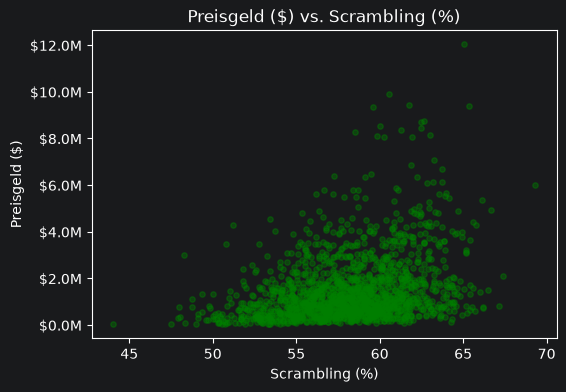

In [25]:
plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["money"], alpha=0.4, s=15, color="green")
geld_achse(plt.gca().yaxis)
plt.xlabel("Scrambling (%)")
plt.ylabel("Preisgeld ($)")
plt.title("Preisgeld ($) vs. Scrambling (%)")
plt.show()

Gutes Scrambling wirkt sich ähnlich stark aus wie eine hohe Driving Distance.

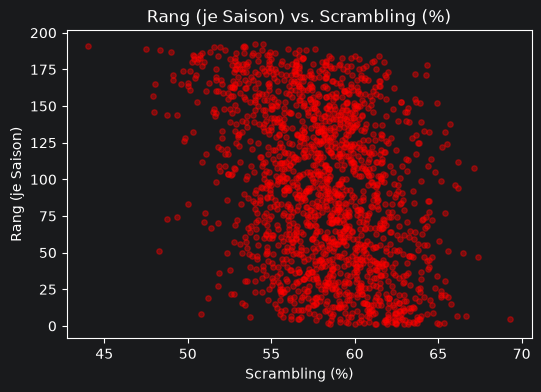

In [26]:
plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["rank"], alpha=0.4, s=15, color="red")
plt.xlabel("Scrambling (%)")
plt.ylabel("Rang (je Saison)")
plt.title("Rang (je Saison) vs. Scrambling (%)")
plt.show()

Spieler mit hohem Scrambling-Wert belegen tendenziell die vorderen (niedrigeren) Ränge.

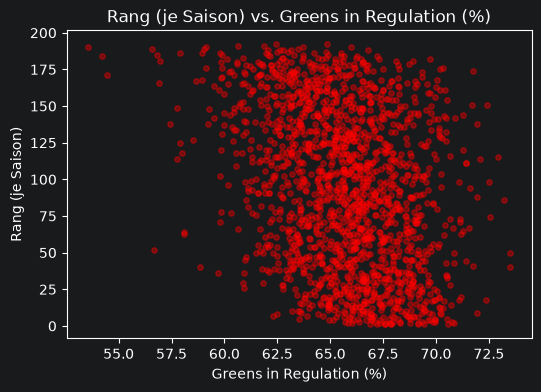

In [27]:
plt.figure(figsize=(6, 4))
plt.scatter(df["gir_pct"], df["rank"], alpha=0.4, s=15, color="red")
plt.xlabel("Greens in Regulation (%)")
plt.ylabel("Rang (je Saison)")
plt.title("Rang (je Saison) vs. Greens in Regulation (%)")
plt.show()

Ein hoher GIR-Prozentsatz hängt mit besseren Rängen zusammen, der Effekt fällt etwas schwächer aus als bei Scrambling.

Um die 8 Variablen auch untereinander zu vergleichen, nutzen wir eine Korrelationsmatrix.

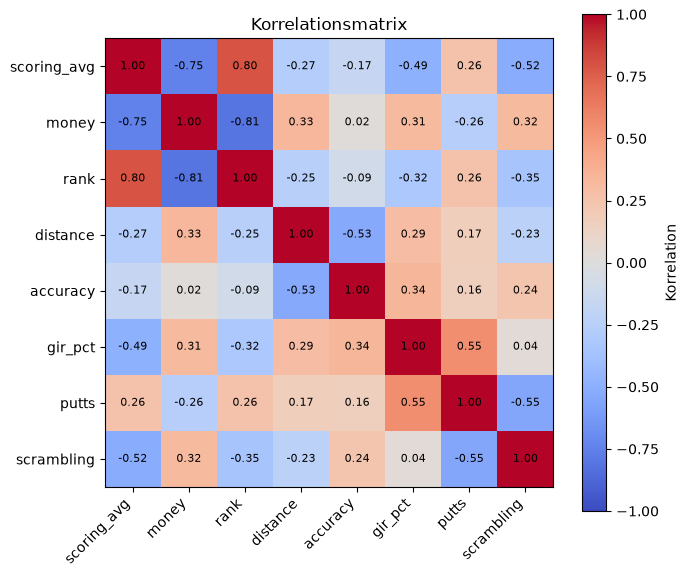

In [20]:
alle_variablen = ["scoring_avg", "money", "rank", "distance", "accuracy", "gir_pct", "putts", "scrambling"]
korr = df[alle_variablen].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(korr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(alle_variablen)))
ax.set_yticks(range(len(alle_variablen)))
ax.set_xticklabels(alle_variablen, rotation=45, ha="right")
ax.set_yticklabels(alle_variablen)
for i in range(len(alle_variablen)):
    for j in range(len(alle_variablen)):
        ax.text(j, i, f"{korr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Korrelation")
ax.set_title("Korrelationsmatrix")
fig.tight_layout()
plt.show()

Zum Schluss noch ein Blick über die Zeit: hat sich am Spiel zwischen 2010 und 2018 etwas verändert?

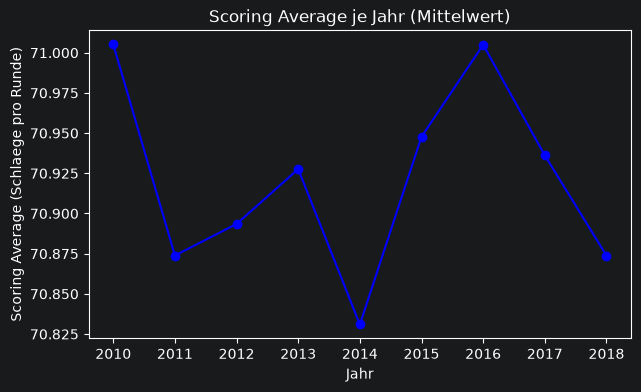

In [29]:
jahres_mittel = df.groupby("Year")[["scoring_avg", "distance"]].mean()

plt.figure(figsize=(7, 4))
plt.plot(jahres_mittel.index, jahres_mittel["scoring_avg"], marker="o", color="blue")
plt.xlabel("Jahr")
plt.ylabel("Scoring Average (Schläge pro Runde)")
plt.title("Scoring Average je Jahr (Mittelwert)")
plt.show()

Der durchschnittliche Scoring Average bleibt über die neun Saisons fast unverändert zwischen 70,8 und
71,0 Schlägen. Trotz technischer Fortschritte spielen die Spieler nicht stark erkennbar besser.

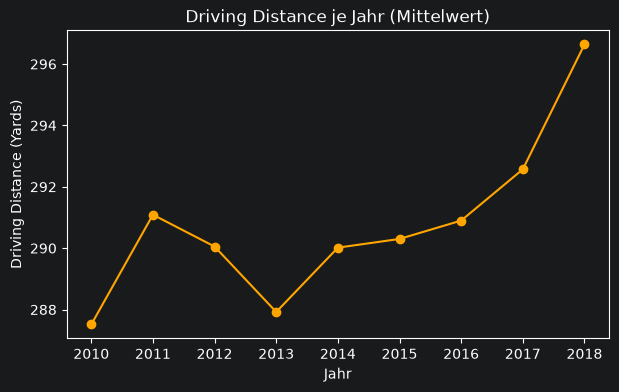

In [30]:
plt.figure(figsize=(7, 4))
plt.plot(jahres_mittel.index, jahres_mittel["distance"], marker="o", color="orange")
plt.xlabel("Jahr")
plt.ylabel("Driving Distance (Yards)")
plt.title("Driving Distance je Jahr (Mittelwert)")
plt.show()

Die Schlaglänge dagegen steigt spürbar, von rund 287 Yards 2010 auf fast 297 Yards 2018. Dass der
Scoring Average trotzdem stabil bleibt, deutet darauf hin, dass sich die Plätze mit verändert und an die größeren Distanzen angepasst haben.

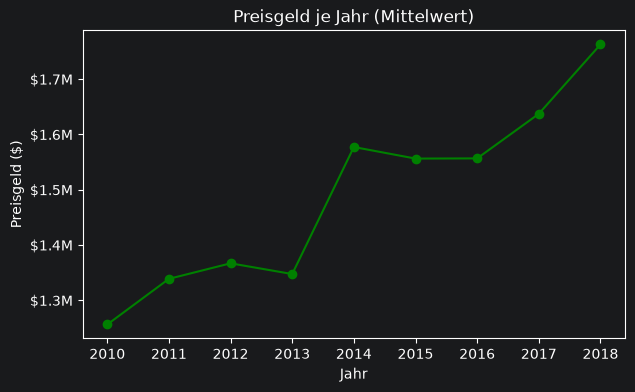

In [31]:
jahres_geld = df.groupby("Year")["money"].mean()

plt.figure(figsize=(7, 4))
plt.plot(jahres_geld.index, jahres_geld.values, marker="o", color="green")
ax = plt.gca()
geld_achse(ax.yaxis)
plt.xlabel("Jahr")
plt.ylabel("Preisgeld ($)")
plt.title("Preisgeld je Jahr (Mittelwert)")
plt.show()

Bis 2013 bewegt sich das durchschnittliche Preisgeld noch um die 1,0 Mio. Dollar, ab 2014 steigt es
Jahr für Jahr an und erreicht 2018 gut 1,3 Mio. Dollar. Das passt zu den in dieser Zeit gestiegenen
Turnierpreisgeldern auf der Tour.

## 4. Regressionsanalyse

Jetzt zum Kern der Analyse: 3 Zielgrößen mal 5 Prädiktoren ergibt 15 einfache lineare Regressionen, jede mit
`statsmodels.formula.api.ols` und der Formel `"ziel ~ praediktor"`. Bewusst keine multiple Regression mit
mehreren Prädiktoren gleichzeitig, und kein Train/Test-Split. Es geht um das Erklären von Zusammenhängen im
vorliegenden Datensatz, nicht um Vorhersagen für neue Spieler. Die p-Werte werden mit ausgegeben, aber nicht
gegen einen festen Schwellenwert wie 0.05 geprüft.

Damit das nicht 15 Mal Copy-Paste wird, übernimmt eine kleine Funktion das Schätzen und Auslesen der
Kennzahlen.

In [33]:
# schätzt ziel ~ praediktor und gibt Intercept, Slope, Standardfehler, p-Wert, R2 und RMSE zurück
def run_simple_regression(df, ziel, praed):
    daten = df[[ziel, praed]].dropna()
    modell = smf.ols(f"{ziel} ~ {praed}", data=daten).fit()
    rmse = np.sqrt(np.mean(modell.resid ** 2))

    return {
        "ziel": ziel,
        "praediktor": praed,
        "intercept": modell.params["Intercept"],
        "slope": modell.params[praed],
        "se_intercept": modell.bse["Intercept"],
        "se_slope": modell.bse[praed],
        "p_wert_slope": modell.pvalues[praed],
        "r_quadrat": modell.rsquared,
        "rmse": rmse,
    }

In [34]:
ergebnisse = []
for ziel in ziel_variablen:
    for praed in praediktoren:
        ergebnisse.append(run_simple_regression(df, ziel, praed))

ergebnis_tabelle = pd.DataFrame(ergebnisse)

### Scoring Average

In [26]:
ergebnis_tabelle[ergebnis_tabelle["ziel"] == "scoring_avg"].sort_values("r_quadrat", ascending=False)

,ziel,praediktor,intercept,slope,se_intercept,se_slope,p_wert_slope,r_quadrat,rmse
4,scoring_avg,scrambling,77.133328,-0.106879,0.250928,0.004310,6.986709e-116,0.268383,0.597115
2,scoring_avg,gir_pct,79.022589,-0.123369,0.357068,0.005433,9.782440e-100,0.235254,0.610484
0,scoring_avg,distance,77.144651,-0.021398,0.535389,0.001840,4.100005e-30,0.074654,0.671534
3,scoring_avg,putts,60.589977,0.354280,0.925812,0.031741,5.911579e-28,0.069190,0.673514
1,scoring_avg,accuracy,72.363882,-0.023469,0.204837,0.003323,2.376708e-12,0.028906,0.687934


Preisgeld als Zielgröße. Die Rechtsschiefe aus Abschnitt 3 lässt hier insgesamt etwas niedrigere R²-Werte erwarten als bei Scoring Average.

In [27]:
ergebnis_tabelle[ergebnis_tabelle["ziel"] == "money"].sort_values("r_quadrat", ascending=False)

,ziel,praediktor,intercept,slope,se_intercept,se_slope,p_wert_slope,r_quadrat,rmse
5,money,distance,-1.367070e+07,52132.404894,1.063551e+06,3655.790161,1.254466e-43,0.108435,1.331277e+06
9,money,scrambling,-6.202411e+06,132329.696170,5.621685e+05,9656.063884,1.367771e-40,0.100983,1.336829e+06
7,money,gir_pct,-9.104398e+06,161314.865905,7.846300e+05,11938.194811,1.452193e-39,0.098452,1.338709e+06
8,money,putts,2.192300e+07,-700680.395965,1.872992e+06,64213.574564,7.937244e-27,0.066478,1.362242e+06
6,money,accuracy,1.210464e+06,4527.640206,4.204027e+05,6818.488351,5.067665e-01,0.000264,1.409726e+06


Und der Rang. Da Rang eine ordinale Größe ist, bei der die Abstände zwischen den Plätzen nicht
zwingend gleich groß sind, bleibt die lineare Regression hier eine Näherung. Mehr dazu in Abschnitt 6.

In [28]:
ergebnis_tabelle[ergebnis_tabelle["ziel"] == "rank"].sort_values("r_quadrat", ascending=False)

,ziel,praediktor,intercept,slope,se_intercept,se_slope,p_wert_slope,r_quadrat,rmse
14,rank,scrambling,417.697354,-5.577890,21.184513,0.363875,9.971170e-50,0.123222,50.376484
12,rank,gir_pct,504.443452,-6.257880,29.885435,0.454709,6.653950e-41,0.101753,50.989524
13,rank,putts,-701.398274,27.256800,71.370547,2.446865,7.495080e-28,0.069088,51.908372
10,rank,distance,540.278617,-1.536429,41.567357,0.142881,4.003145e-26,0.064684,52.031012
11,rank,accuracy,151.782273,-0.948365,15.980195,0.259182,2.609864e-04,0.007944,53.585978


Für die Regressionsgeraden werden dieselben 6 Ziel-Prädiktor-Kombinationen aus Abschnitt 3
wiederverwendet, damit EDA und Regressionsergebnisse zueinander passen.

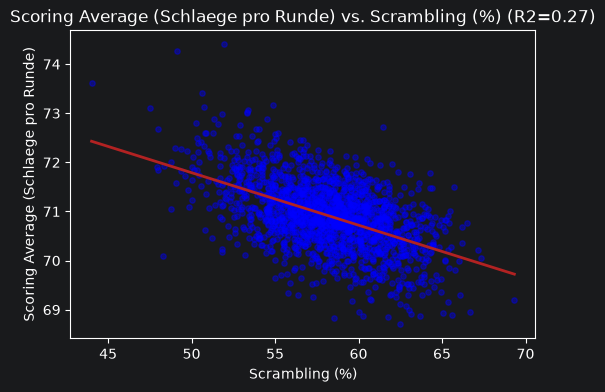

In [35]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "scoring_avg") & (ergebnis_tabelle["praediktor"] == "scrambling")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["scoring_avg"], alpha=0.4, s=15, color="blue")

x_linie = np.linspace(df["scrambling"].min(), df["scrambling"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="firebrick", linewidth=2)
plt.xlabel("Scrambling (%)")
plt.ylabel("Scoring Average (Schläge pro Runde)")
plt.title(f"Scoring Average (Schläge pro Runde) vs. Scrambling (%) (R2={zeile['r_quadrat']:.2f})")
plt.show()

Scrambling erklärt allein rund 27% der Varianz im Scoring Average, mit Abstand der höchste R2-Wert der ganzen Tabelle.

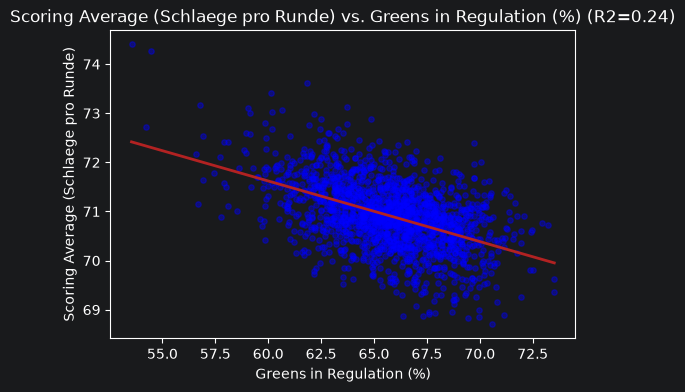

In [36]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "scoring_avg") & (ergebnis_tabelle["praediktor"] == "gir_pct")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["gir_pct"], df["scoring_avg"], alpha=0.4, s=15, color="blue")

x_linie = np.linspace(df["gir_pct"].min(), df["gir_pct"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="firebrick", linewidth=2)
plt.xlabel("Greens in Regulation (%)")
plt.ylabel("Scoring Average (Schläge pro Runde)")
plt.title(f"Scoring Average (Schläge pro Runde) vs. Greens in Regulation (%) (R2={zeile['r_quadrat']:.2f})")
plt.show()

GIR liegt mit einem R2 von 0.24 nur knapp hinter Scrambling und bestätigt damit die Vermutung aus Abschnitt 1.

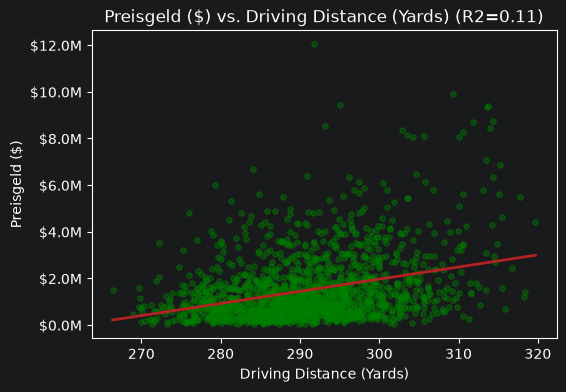

In [37]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "money") & (ergebnis_tabelle["praediktor"] == "distance")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["distance"], df["money"], alpha=0.4, s=15, color="green")

x_linie = np.linspace(df["distance"].min(), df["distance"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="firebrick", linewidth=2)
geld_achse(plt.gca().yaxis)
plt.xlabel("Driving Distance (Yards)")
plt.ylabel("Preisgeld ($)")
plt.title(f"Preisgeld ($) vs. Driving Distance (Yards) (R2={zeile['r_quadrat']:.2f})")
plt.show()

Bei Driving Distance und Preisgeld ist der Zusammenhang mit einem R2 von rund 0.11 klar schwächer als bei Scoring Average.

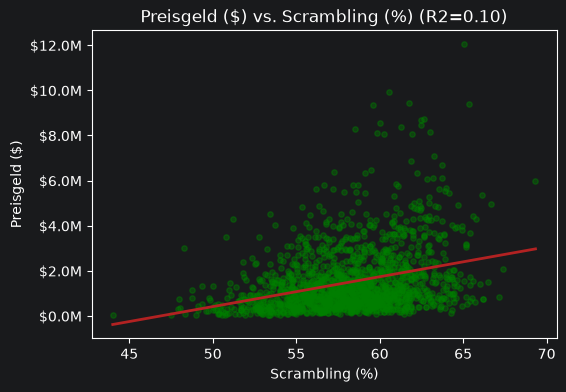

In [38]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "money") & (ergebnis_tabelle["praediktor"] == "scrambling")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["money"], alpha=0.4, s=15, color="green")

x_linie = np.linspace(df["scrambling"].min(), df["scrambling"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="firebrick", linewidth=2)
geld_achse(plt.gca().yaxis)
plt.xlabel("Scrambling (%)")
plt.ylabel("Preisgeld ($)")
plt.title(f"Preisgeld ($) vs. Scrambling (%) (R2={zeile['r_quadrat']:.2f})")
plt.show()

Scrambling erreicht bei Preisgeld ein ähnliches R2 wie Driving Distance, die Gerade steigt dabei ähnlich steil an.

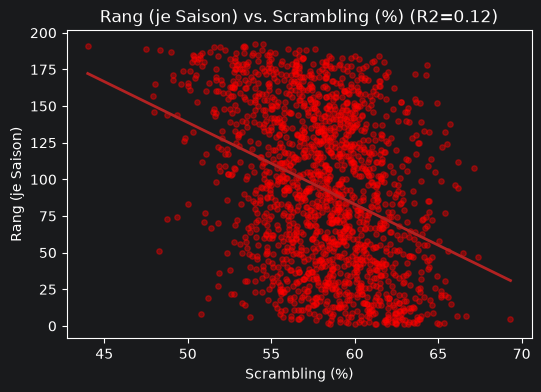

In [39]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "rank") & (ergebnis_tabelle["praediktor"] == "scrambling")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["rank"], alpha=0.4, s=15, color="red")

x_linie = np.linspace(df["scrambling"].min(), df["scrambling"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="firebrick", linewidth=2)
plt.xlabel("Scrambling (%)")
plt.ylabel("Rang (je Saison)")
plt.title(f"Rang (je Saison) vs. Scrambling (%) (R2={zeile['r_quadrat']:.2f})")
plt.show()

Für den Rang liefert Scrambling erneut den höchsten R2-Wert unter den fünf Prädiktoren, wenn auch insgesamt schwächer als bei Scoring Average.

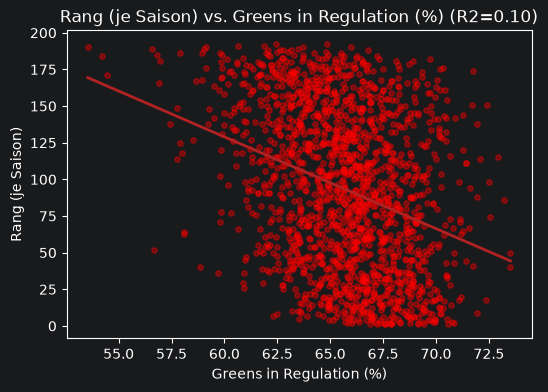

In [40]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "rank") & (ergebnis_tabelle["praediktor"] == "gir_pct")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["gir_pct"], df["rank"], alpha=0.4, s=15, color="red")

x_linie = np.linspace(df["gir_pct"].min(), df["gir_pct"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="firebrick", linewidth=2)
plt.xlabel("Greens in Regulation (%)")
plt.ylabel("Rang (je Saison)")
plt.title(f"Rang (je Saison) vs. Greens in Regulation (%) (R2={zeile['r_quadrat']:.2f})")
plt.show()

GIR fällt beim Rang leicht hinter Scrambling zurück, bleibt aber der zweitstärkste Prädiktor.

## 5. Vergleich der Treiber

Um zu sehen, ob dieselbe Statistik überall den Ton angibt oder die drei Zielgrößen von unterschiedlichen
Dingen abhängen, werden die 5 Prädiktoren je Zielgröße nach R² sortiert.

In [35]:
treiber_tabelle = ergebnis_tabelle.pivot(index="praediktor", columns="ziel", values="r_quadrat")
treiber_tabelle = treiber_tabelle[["scoring_avg", "money", "rank"]]
treiber_tabelle.loc[["distance", "accuracy", "gir_pct", "putts", "scrambling"]]

ziel,scoring_avg,money,rank
praediktor,,,
distance,0.074654,0.108435,0.064684
accuracy,0.028906,0.000264,0.007944
gir_pct,0.235254,0.098452,0.101753
putts,0.069190,0.066478,0.069088
scrambling,0.268383,0.100983,0.123222


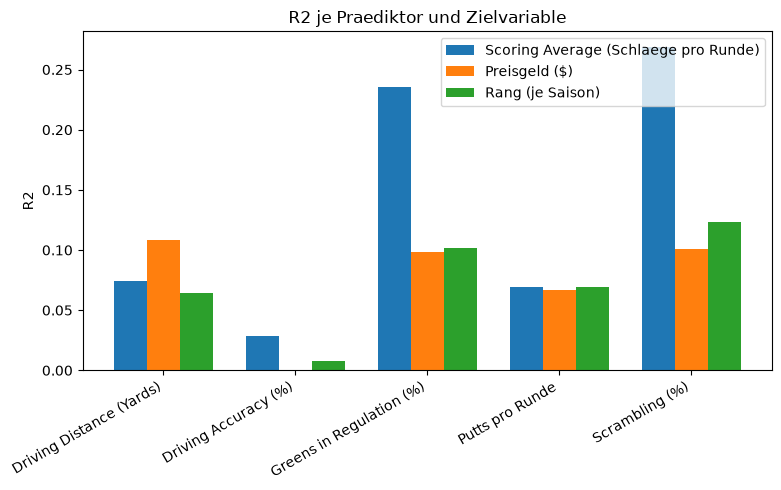

In [36]:
ziel_labels_liste = ["Scoring Average (Schläge pro Runde)", "Preisgeld ($)", "Rang (je Saison)"]
praed_labels_liste = ["Driving Distance (Yards)", "Driving Accuracy (%)", "Greens in Regulation (%)", "Putts pro Runde", "Scrambling (%)"]

x = np.arange(len(praediktoren))
breite = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, ziel in enumerate(ziel_variablen):
    werte = [treiber_tabelle.loc[p, ziel] for p in praediktoren]
    ax.bar(x + i * breite, werte, breite, label=ziel_labels_liste[i])

ax.set_xticks(x + breite)
ax.set_xticklabels(praed_labels_liste, rotation=30, ha="right")
ax.set_ylabel("R2")
ax.set_title("R2 je Prädiktor und Zielvariable")
ax.legend()
fig.tight_layout()
plt.show()

Scrambling sticht bei allen drei Zielgrößen als höchster oder zweithöchster Balken hervor, Driving
Accuracy bleibt dagegen in allen drei Fällen der schwächste Prädiktor.

In [37]:
staerkste_treiber = ergebnis_tabelle.loc[ergebnis_tabelle.groupby("ziel")["r_quadrat"].idxmax()]
staerkste_treiber[["ziel", "praediktor", "r_quadrat"]]

,ziel,praediktor,r_quadrat
5,money,distance,0.108435
14,rank,scrambling,0.123222
4,scoring_avg,scrambling,0.268383


Scrambling führt bei allen drei Zielgrößen die Tabelle an. Das Muster ist also über Scoring Average,
Preisgeld und Rang hinweg erstaunlich konsistent, auch wenn die Stärke des Zusammenhangs je Zielgröße deutlich
schwankt. Für Preisgeld liegt Driving Distance fast gleichauf mit Scrambling, was zeigt: wer verdienen will,
profitiert nicht nur vom kurzen Spiel, ein langes Spiel vom Abschlag zahlt sich finanziell genauso aus.

## 6. Diskussion, Limitationen & Fazit

Ein paar Einschränkungen sollten bei der Interpretation mitgedacht werden.

Der Rang wurde selbst aus den FedExCup-Punkten abgeleitet und ist eine ordinale Größe. Eine lineare Regression
behandelt ihn wie eine stetige Zahl mit gleich großen Abständen zwischen den Werten. Diese Vereinfachung wurde
bewusst in Kauf genommen, um alle drei Zielgrößen mit derselben Methode zu vergleichen.

Auch das Preisgeld ist nicht ganz unproblematisch. Die Verteilung ist stark rechtsschief, ein paar
Top-Verdiener ziehen die linearen Modelle stärker in ihre Richtung, als es bei einer symmetrischeren Verteilung
der Fall wäre. Eine Transformation wurde trotzdem nicht vorgenommen.

Alle Ergebnisse hier sind Korrelationen, keine Kausalaussagen. Ein hoher R² zwischen Scrambling und Scoring
Average bedeutet nicht, dass besseres Scrambling ursächlich zu weniger Schlägen führt. Insgesamt bessere
Spieler schneiden in mehreren Statistiken gleichzeitig gut ab, ohne dass ein einzelner Bereich den anderen
verursacht.

Weil ausschließlich einfache, bivariate Regressionen verwendet wurden, bleibt zudem unberücksichtigt, dass die
5 Prädiktoren untereinander korrelieren, wie die Korrelationsmatrix aus Abschnitt 3 gezeigt hat. Ein Prädiktor
schneidet dadurch teils nur deshalb gut ab, weil er mit einem eigentlich wichtigeren Prädiktor zusammenhängt.
Eine multiple Regression würde solche Effekte trennen, wurde hier aber bewusst nicht eingesetzt.

Die 15 Regressionen zusammengenommen zeigen ein recht konsistentes Bild: Scrambling ist über alle drei
betrachteten Erfolgsgrößen hinweg der stärkste einzelne Prädiktor, bei Preisgeld allerdings dicht gefolgt von
Driving Distance. Erfolg auf der PGA Tour hängt damit weniger an der reinen Schlaglänge als am Umgang mit
verpassten Grüns, jedenfalls wenn man Erfolg über den Scoring Average oder den Rang definiert.